In [13]:
#from google.colab import drive
#drive.mount('/content/drive')

In [14]:
#%cd /content/drive/MyDrive

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
%matplotlib inline  
style.use('fivethirtyeight')
sns.set(style='whitegrid',color_codes=True)
import nltk
nltk.download('omw-1.4')
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.tokenize import word_tokenize,sent_tokenize
nltk.download('wordnet')
from nltk import word_tokenize,sent_tokenize 
from nltk.stem import PorterStemmer,LancasterStemmer 
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer  
from nltk import ne_chunk
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.decomposition import TruncatedSVD

import datetime
# graph
from wordcloud import WordCloud

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [16]:
data = pd.read_csv('abcnews-date-text.csv')
print(data.shape)

(1226258, 2)


In [17]:
date_sorted = sorted(list(data['publish_date']))
print(date_sorted[0], date_sorted[-1])

20030219 20201231


<AxesSubplot:title={'center':'Counts of Headline of Years'}, xlabel='publish_date'>

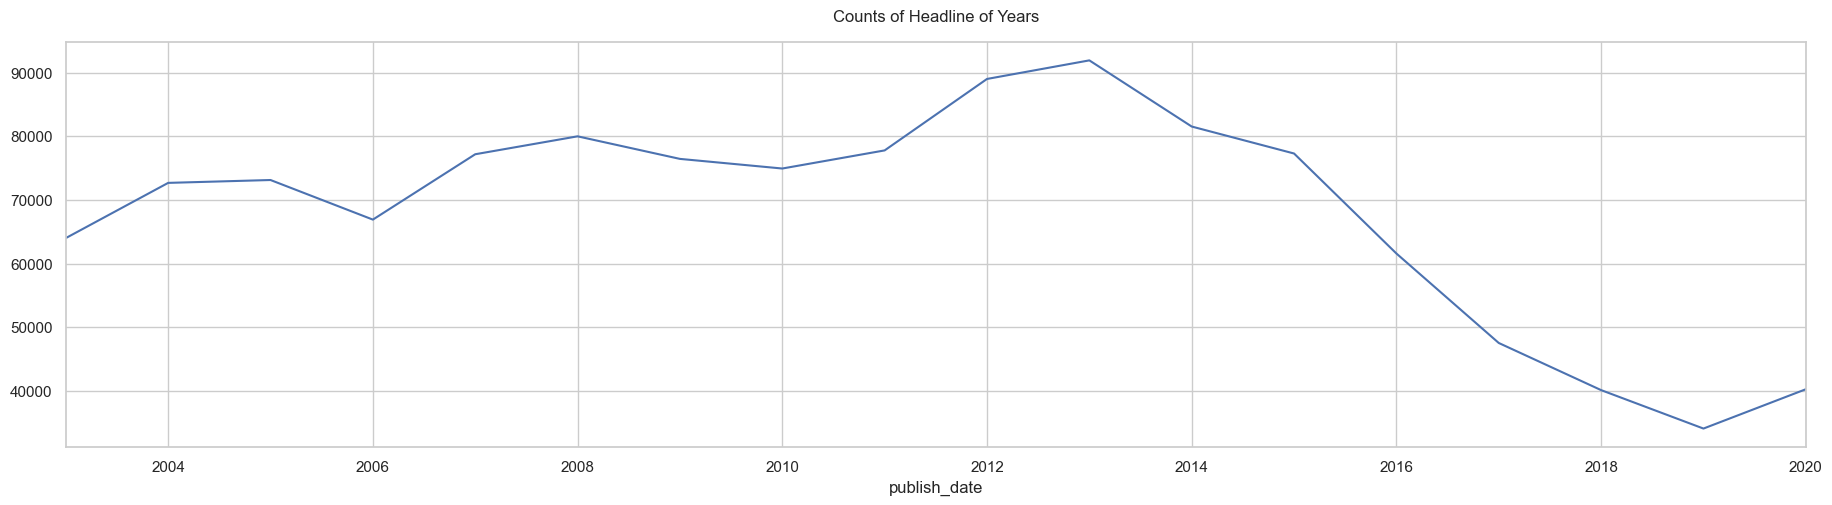

In [18]:
plt.figure(figsize=(20,5),dpi=100,linewidth = 2)
plt.title("Counts of Headline of Years", x=0.5, y=1.03)
data['publish_date'] = pd.to_datetime(data['publish_date'], format="%Y%m%d")
data.resample('A',on = 'publish_date')['headline_text'].count().plot(kind='line')

In [19]:
data.drop(['publish_date'], axis=1, inplace=True)
data.head()

,headline_text
0,aba decides against community broadcasting lic...
1,act fire witnesses must be aware of defamation
2,a g calls for infrastructure protection summit
3,air nz staff in aust strike for pay rise
4,air nz strike to affect australian travellers


Data Clean

In [20]:
stop_words=set(nltk.corpus.stopwords.words('english'))
print(stop_words)

{'have', 'after', 'did', 'on', 've', 'yourselves', 'she', 'him', 'weren', 'below', 'between', 'from', 'it', 'about', 'against', 'up', 'its', 'when', 'own', 'more', 'needn', "aren't", 'wouldn', 'than', 'my', 'into', 'being', 'her', 'whom', 'above', 'while', "wouldn't", 'theirs', 'me', 'he', 'you', 'his', 'what', 'who', 'that', 'but', 'once', 'why', "won't", 'of', 'do', 'couldn', 'or', "doesn't", 'and', 'not', 'don', 'was', 'himself', 'will', 'now', 'where', 'doesn', 'mightn', "you'd", 'am', 'nor', 'to', "hadn't", "you'll", 'each', 'are', 'can', 'just', 'these', 'ain', 'as', 'off', 'both', "mustn't", "needn't", 'again', 'few', 'down', 'themselves', 'this', 'very', 'is', "hasn't", 'a', 'yours', 'aren', 'before', 'didn', 'same', 'out', 'an', 'with', 'be', 'by', 'we', "shan't", 'too', 'should', "wasn't", 'ourselves', 'because', 'here', 'during', 'myself', 'the', "you've", 'how', "don't", 'under', 'in', 'such', 'hasn', "couldn't", "didn't", "should've", 'which', 'll', 'haven', 'were', 't', '

In [21]:
# Remove duplicated headlines
data = data.drop_duplicates(subset=['headline_text'], keep = False)
print(data.shape)

(1185953, 1)


In [22]:
def clean_text(headLine):
  # remove punctuation
  le=WordNetLemmatizer()
  word_tokens=word_tokenize(headLine)
  
  # remove stopword
  tokens=[le.lemmatize(w) for w in word_tokens if w not in stop_words and len(w) > 3]
  cleaned_text=" ".join(tokens)
  return cleaned_text

In [23]:
data['headline_cleaned']=data['headline_text'].apply(clean_text)
data.head()

,headline_text,headline_cleaned
0,aba decides against community broadcasting lic...,decides community broadcasting licence
1,act fire witnesses must be aware of defamation,fire witness must aware defamation
2,a g calls for infrastructure protection summit,call infrastructure protection summit
3,air nz staff in aust strike for pay rise,staff aust strike rise
4,air nz strike to affect australian travellers,strike affect australian traveller


In [24]:
data.drop(['headline_text'], axis=1, inplace=True)
data.head()

,headline_cleaned
0,decides community broadcasting licence
1,fire witness must aware defamation
2,call infrastructure protection summit
3,staff aust strike rise
4,strike affect australian traveller


Using TFidf to extract the features

In [25]:
vec = TfidfVectorizer(stop_words=stop_words,max_features=1000)
vec_text=vec.fit_transform(data['headline_cleaned'])

In [26]:
print(vec_text.shape)
print(vec_text)

(1185953, 1000)
  (0, 509)	0.7833555043157009
  (0, 178)	0.6215739327371232
  (1, 577)	0.6333845621342471
  (1, 983)	0.6360176173661909
  (1, 321)	0.4408010740116697
  (2, 853)	0.6542250319692703
  (2, 683)	0.6234831415977256
  (2, 122)	0.428086883340564
  (3, 744)	0.4539046227610106
  (3, 845)	0.4908474048522162
  (3, 54)	0.5221131804007425
  (3, 829)	0.5295632591464885
  (4, 56)	0.6371206308422673
  (4, 845)	0.7707641025340705
  (5, 978)	1.0
  (6, 710)	1.0
  (7, 544)	0.5177841426380108
  (7, 344)	0.4818749914563097
  (7, 961)	0.5353169396784209
  (7, 53)	0.46166204991847815
  (8, 453)	0.4300409765947477
  (8, 200)	0.3490490663814993
  (8, 777)	0.44823205361768437
  (8, 13)	0.5218790075893285
  (8, 54)	0.46899875826582976
  :	:
  (1185944, 834)	0.377563949138926
  (1185945, 98)	0.5661259082792712
  (1185945, 942)	0.5044737182741936
  (1185945, 550)	0.46222895776789946
  (1185945, 135)	0.45973047989706
  (1185946, 343)	0.6087468731112728
  (1185946, 970)	0.7933645092120317
  (1185947, 

In [27]:
textIDF = vec.idf_
dd=dict(zip(vec.get_feature_names(), textIDF))
textList=sorted(dd,key=(dd).get)
print(textList[0], textList[-1])
print(dd['police'])
print(dd['walk'])

police justice
4.441848852910576
7.899320137442302


c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


{'police': 4.441848852910576, 'say': 4.944592776474849, 'plan': 5.118715966053104, 'council': 5.12297593405179, 'australia': 5.143595221254526, 'call': 5.148389860454045, 'court': 5.185544995044581, 'fire': 5.215701992019947, 'govt': 5.243737422138309, 'back': 5.311103568015399}
Hot Topic


<BarContainer object of 10 artists>

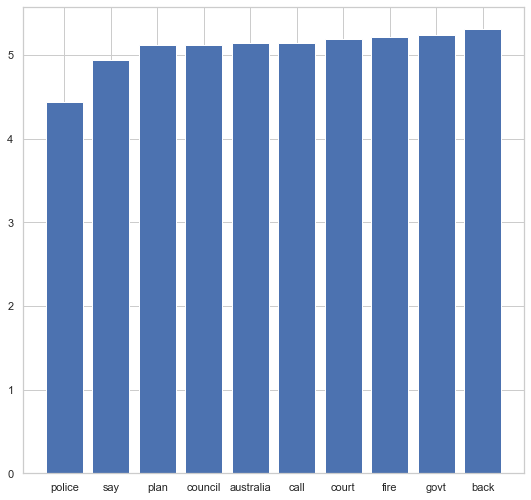

In [28]:
dd_sorted = dict(sorted(dd.items(), key=lambda item: item[1]))
n = 10
first_ten = dict(zip(list(dd_sorted.keys())[:n], list(dd_sorted.values())[:n]))
print(first_ten)

print("Hot Topic")
plt.figure(figsize=(8,8))
plt.bar(list(first_ten.keys()), list(first_ten.values()))

In [29]:
print("Year of the Top Topic")

Year of the Top Topic


Topic Modeling

In [30]:
LSA_model=TruncatedSVD(n_components=10, algorithm='randomized', n_iter=10, random_state=42)
LSA_top=LSA_model.fit_transform(vec_text)
print(LSA_top.shape)
print(LSA_top)

(1185953, 10)
[[ 0.01103893  0.02182396 -0.0100367  ...  0.0020126  -0.00377843
  -0.00235926]
 [ 0.05101141  0.07267575 -0.07304008 ... -0.06756194  0.05671254
   0.00174065]
 [ 0.03881299  0.08931537 -0.08860425 ... -0.06123134  0.01413972
  -0.03355584]
 ...
 [ 0.03589258  0.05995189 -0.0328288  ...  0.05887902 -0.06592618
   0.0173065 ]
 [ 0.01275957  0.02751454 -0.00764896 ...  0.01206556 -0.00864209
  -0.00165071]
 [ 0.07353133  0.06742626 -0.0699224  ...  0.13133221 -0.25117338
   0.01473827]]


In [31]:
l=LSA_top[0]
print("Document 0 :")
for i,topic in enumerate(l):
  print("Topic ",i," : ",topic*100)

Document 0 :
Topic  0  :  1.103892780920363
Topic  1  :  2.1823960042022477
Topic  2  :  -1.0036701379162907
Topic  3  :  -0.87318998409261
Topic  4  :  -0.5795899963153691
Topic  5  :  0.01646762889481071
Topic  6  :  0.1092109931873901
Topic  7  :  0.20125972722014582
Topic  8  :  -0.3778427929136946
Topic  9  :  -0.23592632200541194


Topic 0: 


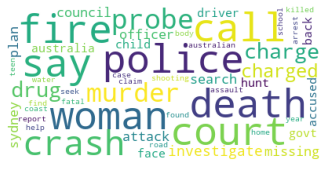

Topic 1: 


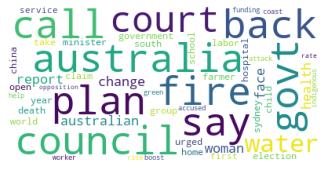

Topic 2: 


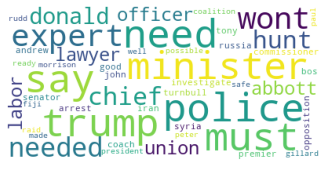

Topic 3: 


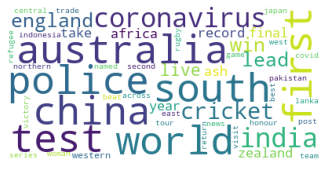

Topic 4: 


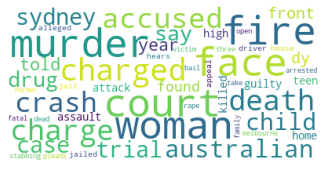

Topic 5: 


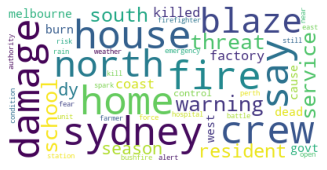

Topic 6: 


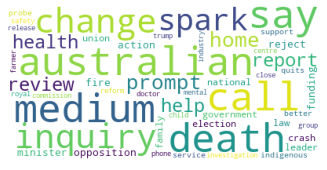

Topic 7: 


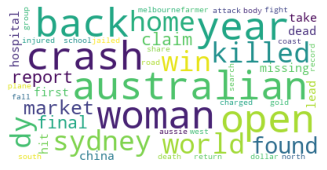

Topic 8: 


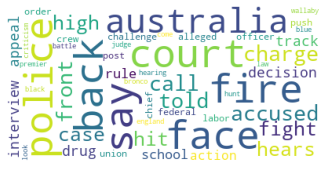

Topic 9: 


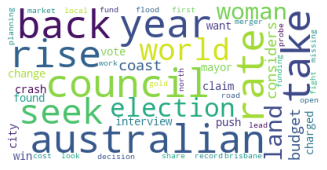

In [32]:
# get most related words of the topic
top_words = vec.get_feature_names_out()

for i, c in enumerate(LSA_model.components_):
  top_topic = ""
  top_words_c = zip(top_words, c)
  words_s = sorted(top_words_c, key= lambda x:x[1], reverse=True)[:50]
  print("Topic " + str(i) + ": ")
  for w in words_s:
    top_topic = top_topic + " " + w[0]
  
  wc = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(top_topic)
  plt.figure(figsize=(5,5))
  plt.imshow(wc)
  plt.axis("off")
  plt.show()

In [33]:
print(top_words['police'])

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
# WordVec
